# <center>Measurement error and specification</center>
### <center>Alfred Galichon (NYU)</center>
## <center>'math+econ+code' masterclass series: econometrics</center>
#### <center>With python code examples</center>

© 2018–2026 by Alfred Galichon. Past and present support from NSF grant DMS-1716489, ERC grant CoG-866274 are acknowledged, as well as inputs from contributors listed [here](http://www.math-econ-code.org/team).

**If you reuse material from this masterclass, please cite as:**<br>
Alfred Galichon, 'math+econ+code' masterclass series. https://www.math-econ-code.org/

### Learning objectives

* Derive attenuation bias and the reliability ratio.
* Contrast classical measurement error in a regressor and in an outcome.
* Use a second measurement as an instrument.
* Apply RESET to functional form and Durbin–Wu–Hausman to endogeneity.

### References

**[Wo]** Wooldridge, J. M. (2010). *Econometric Analysis of Cross Section and Panel Data* (2nd ed.). MIT Press, ch. 4 & 5.

**[BBM]** Bound, J., Brown, C., and Mathiowetz, N. (2001). 'Measurement Error in Survey Data'. In *Handbook of Econometrics*, vol. 5, 3705–3843.

**[Ram]** Ramsey, J. B. (1969). 'Tests for Specification Errors in Classical Linear Least-Squares Regression Analysis'. *JRSS-B*, 31(2), 350–371.

**[D]** Durbin, J. (1954). 'Errors in Variables'. *Review of the International Statistical Institute*, 22(1/3), 23–32.

**[Wu]** Wu, D.-M. (1973). 'Alternative Tests of Independence Between Stochastic Regressors and Disturbances'. *Econometrica*, 41(4), 733–750.

**[Hau]** Hausman, J. A. (1978). 'Specification Tests in Econometrics'. *Econometrica*, 46(6), 1251–1271.

# Motivation: when the data are not the variables in the theory

Economic models are written in terms of income, skill, productivity, treatment, or risk. The data often contain proxies. A credible research design does not repair a poor link between the theoretical variable and its measurement.

Measurement error in a regressor creates endogeneity and can destroy consistency. Misspecified functional form can do the same. This lecture studies the leading measurement-error result, an IV correction, and two specification tests.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from types import SimpleNamespace
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset
rng = np.random.default_rng(0)

def slope(X_i, Y_i):
    Xc_i = X_i - X_i.mean()
    Yc_i = Y_i - Y_i.mean()
    return (Xc_i @ Yc_i) / (Xc_i @ Xc_i)

# The house OLS helper, as in Lectures 3-5, so the specification tests below can be built
# from the same primitives as everything else in the series rather than called out to a
# library and taken on trust.
def ols(X_i_k, y_i):
    XtXinv_k_k = np.linalg.inv(X_i_k.T @ X_i_k)
    β_k = XtXinv_k_k @ (X_i_k.T @ y_i)
    εhat_i = y_i - X_i_k @ β_k
    return SimpleNamespace(β_k=β_k, εhat_i=εhat_i, XtXinv_k_k=XtXinv_k_k,
                           I=len(y_i), K=X_i_k.shape[1])

def vcov_hc1(X_i_k, εhat_i, XtXinv_k_k):
    """Eicker–White with the HC1 degrees-of-freedom correction I/(I-K)."""
    I_, K_ = X_i_k.shape
    filling_k_k = (X_i_k * (εhat_i ** 2)[:, None]).T @ X_i_k
    return (I_ / (I_ - K_)) * XtXinv_k_k @ filling_k_k @ XtXinv_k_k


# 1. Classical measurement error: attenuation bias

## 1.1 A single mismeasured regressor

Suppose

$$
Y_i=\beta_0+\beta X_i^\ast+\varepsilon_i,
\qquad
X_i=X_i^\ast+u_i,
$$

where $u_i\perp(X_i^\ast,\varepsilon_i)$ and $\mathbb E[u_i]=0$. We observe $X_i$, not $X_i^\ast$. Then

$$
\hat\beta\xrightarrow{p}
\beta\underbrace{\frac{\operatorname{Var}(X^\ast)}
{\operatorname{Var}(X^\ast)+\operatorname{Var}(u)}}_{\lambda\text{: reliability ratio}}.
$$

Since $0<\lambda<1$, OLS is biased toward zero. Measurement error raises $\operatorname{Var}(X)$ without raising $\operatorname{Cov}(X,Y)$.

**A wage example.** Let $Y_i$ be log hourly wages, $X_i^\ast$ a worker's standardized productive skill, and $X_i$ a noisy skills-test score. The error $u_i$ captures test-day and scoring noise, independent of skill and the wage disturbance. The simulation normalizes $\beta=1$ and $\operatorname{Var}(X^\ast)=1$. Each value of $\operatorname{Var}(u)$ represents a test with different reliability; the table and figure compare the estimated slope with $\beta\lambda$.

The attenuation formula is narrow: one regressor and classical error. Non-classical error can bias in either direction; with several regressors, even coefficients on accurately measured variables can be biased.

In [2]:
I = 5_000
beta = 1.0

# Wage story: true skill X* affects log wages Y; a test observes X = X* + u.
Xstar_i = rng.normal(0, 1, I)
Y_i = 0.5 + beta * Xstar_i + rng.normal(0, 1, I)

print("test-score error variance -> OLS slope:")
var_u_grid = [0.0, 0.25, 0.5, 1.0, 2.0, 4.0]
for var_u in var_u_grid:
    X_i = Xstar_i + rng.normal(0, np.sqrt(var_u), I)
    reliability = 1 / (1 + var_u)
    print(
        f"  Var(u) = {var_u:4.2f}:  OLS slope = {slope(X_i, Y_i):.3f}   "
        f"(reliability = {reliability:.3f}, predicted = {beta * reliability:.3f})"
    )


test-score error variance -> OLS slope:
  Var(u) = 0.00:  OLS slope = 1.014   (reliability = 1.000, predicted = 1.000)
  Var(u) = 0.25:  OLS slope = 0.820   (reliability = 0.800, predicted = 0.800)
  Var(u) = 0.50:  OLS slope = 0.663   (reliability = 0.667, predicted = 0.667)
  Var(u) = 1.00:  OLS slope = 0.513   (reliability = 0.500, predicted = 0.500)
  Var(u) = 2.00:  OLS slope = 0.331   (reliability = 0.333, predicted = 0.333)
  Var(u) = 4.00:  OLS slope = 0.185   (reliability = 0.200, predicted = 0.200)


In [3]:
# Estimated return to skill as the test becomes less reliable
P = 40
var_u_p = np.linspace(0, 4, P)
beta_hat_p = np.array(
    [slope(Xstar_i + rng.normal(0, np.sqrt(var_u), I), Y_i) for var_u in var_u_p]
)


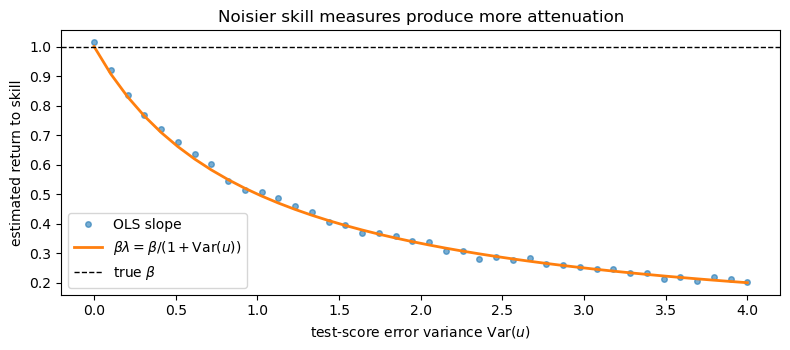

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(var_u_p, beta_hat_p, "o", ms=4, alpha=0.6, label="OLS slope")
ax.plot(
    var_u_p,
    beta / (1 + var_u_p),
    "C1",
    lw=2,
    label=r"$\beta\lambda=\beta/(1+\mathrm{Var}(u))$",
)
ax.axhline(beta, color="k", ls="--", lw=1, label=r"true $\beta$")
ax.set_xlabel(r"test-score error variance $\mathrm{Var}(u)$")
ax.set_ylabel("estimated return to skill")
ax.set_title("Noisier skill measures produce more attenuation")
ax.legend()
plt.tight_layout()
plt.show()


## 1.2 More than one regressor

**Question.** How does measurement error in $X_1$ affect the OLS estimator of its own partial effect, $\beta_1$, when $X_1$ is correlated with an accurately measured regressor $X_2$?

Extend the wage example:

$$
Y_i=\beta_0+\beta_1X_{1i}^\ast+\beta_2X_{2i}+\varepsilon_i.
$$

Let $X_{1i}^\ast$ be true skill and $X_{2i}$ standardized, accurately measured education. Skill and education are correlated, but only skill is measured with error: $X_{1i}=X_{1i}^\ast+u_i$.

By the Frisch--Waugh--Lovell theorem, $\beta_1$ is identified from the variation in true skill left after projecting it on education. Define

$$
\widetilde X_{1i}^\ast
=X_{1i}^\ast-\operatorname{Proj}(X_{1i}^\ast\mid 1,X_{2i}).
$$

Under classical measurement error, residualizing the observed skill measure gives $\widetilde X_{1i}=\widetilde X_{1i}^\ast+u_i$. The relevant attenuation factor is therefore

$$
\lambda_{1\mid2}=
\frac{\operatorname{Var}(\widetilde X_1^\ast)}
{\operatorname{Var}(\widetilde X_1^\ast)+\operatorname{Var}(u)}.
$$

Here both regressors have variance one and correlation $\rho$. Hence $\operatorname{Var}(\widetilde X_1^\ast)=1-\rho^2$, so the formula used below is

$$
\lambda_{1\mid2}(\operatorname{Var}(u))=
\frac{1-\rho^2}{1-\rho^2+\operatorname{Var}(u)}.
$$

At $\operatorname{Var}(u)=1$, this becomes $(1-\rho^2)/(1-\rho^2+1)$, exactly the expression computed in Python.

This partial reliability ratio is smaller than the naive one. A secondary consequence is that $\hat\beta_2$ is also inconsistent: as the skill score deteriorates, education proxies for the missing skill signal. In the simulation its coefficient rises above the truth.

In [5]:
rng_multi = np.random.default_rng(11)
rho = 0.7

# X1*: true skill; X2: standardized, accurately measured education; Y: log wage.
X1star_i = rng_multi.normal(0, 1, I)
X2_i = rho * X1star_i + np.sqrt(1 - rho**2) * rng_multi.normal(0, 1, I)
beta1 = beta2 = 1.0
Y_multi_i = (
    0.5
    + beta1 * X1star_i
    + beta2 * X2_i
    + rng_multi.normal(0, 1, I)
)

print("Y: log wage; X1*: true skill; X2: standardized education; only skill is mismeasured")
print()
print(f'{"Var(u)":>8}{"beta1_hat":>12}{"beta2_hat":>12}   naive reliability')

for var_u in [0.0, 0.5, 1.0, 2.0]:
    X1_i = X1star_i + rng_multi.normal(0, np.sqrt(var_u), I)
    X_multi_i_k = np.column_stack([np.ones(I), X1_i, X2_i])
    beta_hat_k = np.linalg.lstsq(X_multi_i_k, Y_multi_i, rcond=None)[0]
    print(
        f"{var_u:>8.2f}{beta_hat_k[1]:>12.3f}{beta_hat_k[2]:>12.3f}"
        f"   {1 / (1 + var_u):>17.3f}"
    )

lambda_partial = (1 - rho**2) / ((1 - rho**2) + 1.0)
print()
print(f"At Var(u)=1, the partial reliability ratio is {lambda_partial:.3f}.")
print("Education's coefficient rises because it proxies for mismeasured skill.")


Y: log wage; X1*: true skill; X2: standardized education; only skill is mismeasured

  Var(u)   beta1_hat   beta2_hat   naive reliability
    0.00       1.003       0.988               1.000
    0.50       0.502       1.332               0.667
    1.00       0.325       1.449               0.500
    2.00       0.202       1.545               0.333

At Var(u)=1, the partial reliability ratio is 0.338.
Education's coefficient rises because it proxies for mismeasured skill.


# 2. Error in the outcome: consistent, but noisier

Let the error-free outcome satisfy

$$
Y_i^\ast=\beta_0+\beta X_i+\varepsilon_i.
$$

We observe

$$
Y_i=Y_i^\ast+v_i,
\qquad v_i\perp(X_i,\varepsilon_i).
$$

Hence

$$
Y_i=\beta_0+\beta X_i+(\varepsilon_i+v_i).
$$

Classical outcome error enlarges the disturbance but does not bias the slope. In the wage example, independent reporting noise makes the estimate less precise, not inconsistent.

Three qualifications:

* If $v_i$ is correlated with $X_i$, the slope is biased.
* Transforming a contaminated outcome or misclassifying a discrete outcome generally destroys the additive mean-zero structure.
* A larger residual variance means wider confidence intervals and less power.

In [6]:
# Ystar_i is the error-free log wage from Section 1.
Ystar_i = Y_i.copy()

# Yreported_i is observed with independent reporting noise.
Yreported_i = Ystar_i + rng.normal(0, 1.5, I)
print(f"slope of Y*         on skill = {slope(Xstar_i, Ystar_i):.3f}")
print(f"slope of observed Y on skill = {slope(Xstar_i, Yreported_i):.3f}")

# Reporting error correlated with skill is not classical.
Ycorrelated_i = Ystar_i + 0.8 * Xstar_i * rng.normal(1, 0.2, I)
print(f"slope with skill-correlated outcome error = {slope(Xstar_i, Ycorrelated_i):.3f}")


slope of Y*         on skill = 1.014
slope of observed Y on skill = 0.989
slope with skill-correlated outcome error = 1.810


# 3. The fix: instrument the mismeasured regressor

With $X_1=X^\ast+u_1$, the regression disturbance is $\varepsilon-\beta u_1$, so $X_1$ is endogenous. Suppose a second skills test provides

$$
X_2=X^\ast+u_2.
$$

If $u_2\perp u_1$ and $u_2\perp\varepsilon$, then $X_2$ is a valid instrument for $X_1$ and

$$
\hat\beta_{\mathrm{IV}}
=\frac{\operatorname{Cov}(X_2,Y)}{\operatorname{Cov}(X_2,X_1)}
\xrightarrow{p}\beta.
$$

Relevance follows from the common signal $X^\ast$. Exclusion is the difficult condition: two tests administered or scored in the same way may share an error. A valid second measurement removes attenuation, but IV is typically less precise than OLS.

In [7]:
# Two independent skills tests of the same latent skill X*.
X1_i = Xstar_i + rng.normal(0, 1, I)
X2_i = Xstar_i + rng.normal(0, 1, I)

beta_ols = slope(X1_i, Y_i)
beta_iv = np.cov(X2_i, Y_i)[0, 1] / np.cov(X2_i, X1_i)[0, 1]
print(f"OLS using test 1 = {beta_ols:.3f}   (attenuated)")
print(f"IV using test 2  = {beta_iv:.3f}   (recovers beta = {beta:.0f})")


OLS using test 1 = 0.511   (attenuated)
IV using test 2  = 1.009   (recovers beta = 1)


# 4. Testing the functional form: the RESET test

Under the null, the linear conditional mean is correctly specified: $E[Y_i\mid X_i]=X_i'\beta$. Ramsey's RESET estimates an augmented regression such as

$$
Y_i=X_i'\beta+\gamma_2\widehat Y_i^2+\gamma_3\widehat Y_i^3+e_i
$$

and tests $H_0:\gamma_2=\gamma_3=0$. If $X_i'\beta$ already contains the whole conditional mean, powers of $\widehat Y_i$ provide no additional explanatory power after controlling for $X_i$. Thus *irrelevant* means that their population coefficients are zero: not that these terms are uncorrelated with $Y_i$ on their own. Omitted curvature or interactions may make them significant proxies for the missing structure.

A small $p$-value indicates misspecification, but does not identify the missing term. RESET also
has limited power against alternatives unrelated to powers of the fitted index. We use an HC1
covariance so heteroskedasticity is not mistaken for nonlinearity.

The test is three steps and we write all three out, rather than calling a library routine and
trusting the number that comes back:

1. Fit the maintained linear model and form the fitted index $\widehat Y_i = X_i'\hat\beta$.
2. Refit with $\widehat Y_i^2$ and $\widehat Y_i^3$ appended to the regressor matrix.
3. Wald-test the two added coefficients jointly, using the HC1 covariance of the *augmented*
   regression, and report it in $F$ form as $W/Q$ against $F_{Q,\,I-K}$.

`statsmodels.stats.diagnostic.linear_reset` is then run on the same data as a check on the
implementation, exactly as Lectures 3, 7 and 10 check their DIY estimators against library
counterparts.

In [8]:
def reset_test(y_i, X_i_k, power=3):
    """Ramsey's RESET, built from the house `ols` helper.

    Augments the regression with powers 2..`power` of the fitted index and jointly tests the
    added coefficients with an HC1 covariance, reported in F form.
    """
    fit0 = ols(X_i_k, y_i)
    yhat_i = X_i_k @ fit0.β_k
    powers_i_q = np.column_stack([yhat_i ** p for p in range(2, power + 1)])
    Xaug_i_k = np.column_stack([X_i_k, powers_i_q])

    fit1 = ols(Xaug_i_k, y_i)
    V_k_k = vcov_hc1(Xaug_i_k, fit1.εhat_i, fit1.XtXinv_k_k)

    Q, K = powers_i_q.shape[1], Xaug_i_k.shape[1]
    R_q_k = np.zeros((Q, K))
    R_q_k[np.arange(Q), np.arange(K - Q, K)] = 1.0          # select the appended powers
    dev_q = R_q_k @ fit1.β_k
    W = dev_q @ np.linalg.solve(R_q_k @ V_k_k @ R_q_k.T, dev_q)
    F = W / Q
    df_denom = fit1.I - K
    return SimpleNamespace(F=F, p=1 - stats.f.cdf(F, Q, df_denom), Q=Q, df_denom=df_denom)


rng_reset = np.random.default_rng(3)              # independent draw for a clean illustration
X_reset_i = rng_reset.normal(0, 1, I)
Y_linear_i = 1 + 2 * X_reset_i + rng_reset.normal(0, 1, I)                     # correctly linear
Y_quad_i   = 1 + 2 * X_reset_i + 1.5 * X_reset_i**2 + rng_reset.normal(0, 1, I)       # true model is quadratic

Xr_i_k = np.column_stack([np.ones(I), X_reset_i])
res_ok  = reset_test(Y_linear_i, Xr_i_k, power=3)
res_bad = reset_test(Y_quad_i,   Xr_i_k, power=3)      # a LINEAR model fitted to quadratic data

print(f"{'':<34s}{'F':>12s}{'p-value':>12s}")
print(f'{"correctly specified linear model":<34s}{res_ok.F:>12.4f}{res_ok.p:>12.3f}'
      f'   (>0.05: no evidence of misspecification)')
print(f'{"omitted quadratic term":<34s}{res_bad.F:>12.4f}{res_bad.p:>12.2e}'
      f'   (rejects: functional form is wrong)')
print(f'\nreference distribution: F({res_ok.Q}, {res_ok.df_denom})')

# Check against statsmodels on the same data.
fit_ok  = sm.OLS(Y_linear_i, sm.add_constant(X_reset_i)).fit()
fit_bad = sm.OLS(Y_quad_i,   sm.add_constant(X_reset_i)).fit()
sm_ok  = linear_reset(fit_ok,  power=3, use_f=True, cov_type='HC1')
sm_bad = linear_reset(fit_bad, power=3, use_f=True, cov_type='HC1')
print(f'\nmax |F_DIY - F_statsmodels| = '
      f'{max(abs(res_ok.F - sm_ok.statistic), abs(res_bad.F - sm_bad.statistic)):.2e}')
assert abs(res_ok.F - sm_ok.statistic) < 1e-8 * max(1.0, abs(sm_ok.statistic))
assert abs(res_bad.F - sm_bad.statistic) < 1e-8 * max(1.0, abs(sm_bad.statistic))
print('DIY RESET reproduces statsmodels.linear_reset.')


                                             F     p-value
correctly specified linear model        0.5401       0.583   (>0.05: no evidence of misspecification)
omitted quadratic term              10328.7299    1.11e-16   (rejects: functional form is wrong)

reference distribution: F(2, 4996)

max |F_DIY - F_statsmodels| = 1.42e-10
DIY RESET reproduces statsmodels.linear_reset.


# 5. Testing for endogeneity: Durbin–Wu–Hausman

With a valid instrument, Durbin–Wu–Hausman tests the null that the suspect regressor is exogenous. Write the first stage as

$$
X_i=Z_i'\pi+v_i.
$$

The control-function version used here is:

1. Regress $X_i$ on $Z_i$ and obtain $\widehat v_i$.
2. Estimate $Y_i=\beta_0+\beta X_i+\delta\widehat v_i+e_i$.
3. Test $H_0:\delta=0$ with a robust covariance.

If $X_i$ is endogenous, $\widehat v_i$ contains the component of $X_i$ correlated with the structural error, so its coefficient is nonzero.

As with RESET, both regressions are run through the house `ols` helper with an HC1 covariance, and the result is checked against the equivalent `statsmodels` fit. Note one detail because it is a common source of small discrepancies: with a robust covariance the coefficient on $\widehat v_i$ is referred to the **normal** rather than to $t_{I-K}$, which is also what `statsmodels` does for `cov_type='HC1'`. At $I = 5{,}000$ the two give the same answer to three decimals, but the identity check below is exact only under the same convention.

**Relation to the Hausman test in Lecture 10.** There we compared OLS and 2SLS directly:

$$
H=(\widehat\beta_{\mathrm{2SLS}}-\widehat\beta_{\mathrm{OLS}})'
\left(\widehat V_{\mathrm{2SLS}}-\widehat V_{\mathrm{OLS}}\right)^{-1}
(\widehat\beta_{\mathrm{2SLS}}-\widehat\beta_{\mathrm{OLS}}).
$$

Under exogeneity, both estimators are consistent and should be close; under endogeneity, only IV is consistent. Under the standard linear-IV assumptions, this estimator-comparison Hausman test and the residual-inclusion DWH test are asymptotically equivalent tests of the same null. Lecture 10 used the classical homoskedastic covariance-difference formula; here we use the control-function form with HC1.

Both interpretations are conditional on instrument validity. Weak instruments give low-power tests, and non-rejection is not proof of exogeneity. With additional exogenous controls, include them in both stages.

In [9]:
def dwh_test(Y_i, X_i, Z_i):
    """Durbin–Wu–Hausman in control-function form, built from the house `ols` helper.

    Note the reference distribution: with a robust covariance the coefficient on v̂ is
    referred to the normal, not to t(I-K), which is also what statsmodels does for
    `cov_type='HC1'`. At this sample size the distinction is immaterial, but the identity
    check below would not pass without it.
    """
    Z_i_l = np.column_stack([np.ones(len(Z_i)), Z_i])
    v_i = ols(Z_i_l, X_i).εhat_i                       # first-stage residual

    Xaug_i_k = np.column_stack([np.ones(len(Y_i)), X_i, v_i])
    fit = ols(Xaug_i_k, Y_i)
    V_k_k = vcov_hc1(Xaug_i_k, fit.εhat_i, fit.XtXinv_k_k)

    δ = fit.β_k[2]                                     # coefficient on v̂
    se_δ = np.sqrt(V_k_k[2, 2])
    t = δ / se_δ
    return SimpleNamespace(δ=δ, se=se_δ, t=t, p=2 * (1 - stats.norm.cdf(abs(t))))


def dwh_pvalue(Y_i, X_i, Z_i):
    return dwh_test(Y_i, X_i, Z_i).p


res_bad  = dwh_test(Y_i, X1_i, X2_i)          # X1 is mismeasured, so endogenous
res_good = dwh_test(Y_i, Xstar_i, X2_i)       # X* is the error-free regressor

print(f"{'':<28s}{'δ̂ on v̂':>10s}{'s.e.':>10s}{'t':>10s}{'p-value':>12s}")
for label, r in (('mismeasured X1', res_bad), ('error-free X*', res_good)):
    print(f'{label:<28s}{r.δ:>10.4f}{r.se:>10.4f}{r.t:>10.3f}{r.p:>12.2e}')

# Same check as for RESET: rebuild the test through statsmodels and compare.
def dwh_statsmodels(Y_i, X_i, Z_i):
    v_i = sm.OLS(X_i, sm.add_constant(Z_i)).fit().resid
    fit = sm.OLS(Y_i, sm.add_constant(np.column_stack([X_i, v_i]))).fit(cov_type='HC1')
    return fit.params[2], fit.pvalues[2]

gap = 0.0
for r, (X_i, ) in ((res_bad, (X1_i, )), (res_good, (Xstar_i, ))):
    δ_sm, p_sm = dwh_statsmodels(Y_i, X_i, X2_i)
    gap = max(gap, abs(r.δ - δ_sm), abs(r.p - p_sm))
print(f'\nmax |DIY - statsmodels| over coefficient and p-value = {gap:.2e}')
assert gap < 1e-8, 'DIY DWH does not reproduce the statsmodels control-function regression'
print('DIY DWH reproduces the statsmodels control-function regression.')


                              δ̂ on v̂      s.e.         t     p-value
mismeasured X1                 -0.6575    0.0275   -23.939    0.00e+00
error-free X*                   0.0014    0.0288     0.050    9.61e-01

max |DIY - statsmodels| over coefficient and p-value = 1.49e-13
DIY DWH reproduces the statsmodels control-function regression.


# Looking back, and ahead

This closes the linear-model half of the course. The recurring question has been: **when does an estimated number have the economic meaning we assign to it?**

Lectures 1–7 developed estimation and inference for linear and panel models: the asymptotic toolkit, OLS in finite samples and in the limit, GLS, the delta method and Wald tests, and panel data. Lectures 8–10, together with the causal-inference lectures (`ci01`–`ci04`), studied estimators and research designs that make comparisons credible: maximum likelihood, GMM, instrumental variables, potential outcomes, difference-in-differences, regression discontinuity, and matching. This lecture adds a final warning: identification applies to the variables actually measured and the model actually estimated.

The remaining lectures turn to the bootstrap (Lecture 12), machine-learning-based estimation of high-dimensional nuisance components (Lecture 13), and limited dependent variables (Lecture 14).